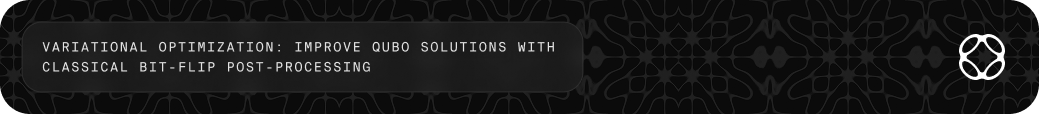

This notebook focuses on **`haiqu.postprocess()` at scale**: we reuse pre-measured counts from a 120-qubit graph optimization run and show how classical refinement closes the optimality gap.

- **Problem intake:** standard CPLEX **`.lp`** file via `ModelReader.read`, `from_docplex_mp`, and `to_unconstrained_problem`.
- **CPLEX (optional):** The committed artifact is IBM CPLEX LP format. Reading `.lp` with Docplex needs the **IBM CPLEX runtime**, which is **not** in sdk-examples `requirements.txt`. Install when needed: `pip install 'qiskit-addon-opt-mapper[cplex]'` (or `pip install cplex`) and ensure CPLEX is on your machine (for example IBM ILOG CPLEX Optimization Studio on macOS).
- **Scoring:** `evaluate_problem_cost` and `cvar_expectation` (via thin `summarize_counts` helpers in the notebook).
- **Counts:** baked-in `graph_optimization_120q/mps_counts_trained.json` so you can learn post-processing without re-running the variational training job.

To build the LR-QAOA circuit and inspect it with `circuit.draw()` before `haiqu.run`, start with [`haiqu_solve_qubo.ipynb`](haiqu_solve_qubo.ipynb).


### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.postprocess()`

- **What does it do?** Applies Haiqu's classical search (bit-flip and related heuristics) on measured bitstrings.
- **Inputs:** A counts or probability dict plus the same `OptimizationProblem` used for the run.
- **Knobs:** `postprocess_iterations` (try 1, then 5–10) and optional `seed` for reproducibility.

## 1. Load the 120-qubit `OptimizationProblem`


**Important:** Post-processing calls the Haiqu API and requires `haiqu.login()`. The problem is the committed CPLEX LP `graph_optimization_120q/seq_6434_c.lp` (120 binary variables).

**CPLEX for `.lp` read:** Docplex `ModelReader.read` needs the IBM CPLEX runtime. It is not in sdk-examples `requirements.txt`. If the load cell fails, install CPLEX support with `pip install 'qiskit-addon-opt-mapper[cplex]'` (or `pip install cplex`) and ensure CPLEX is available locally (typical on macOS via IBM ILOG CPLEX Optimization Studio).


In [1]:
import json

import pandas as pd
from docplex.mp.model_reader import ModelReader
from qiskit_addon_opt_mapper.translators import from_docplex_mp

from haiqu.sdk import haiqu
from haiqu.sdk.optimization import (
    cvar_expectation,
    evaluate_problem_cost,
    to_unconstrained_problem,
    validate_optimization_problem,
)

pd.set_option("display.max_colwidth", None)

haiqu.login()
haiqu.init("Postprocess at Scale Tutorial")


'Set current experiment to: Postprocess at Scale Tutorial. View on Dashboard: https://dashboard.haiqu.ai/experiment/exp-46a398fc-e7d3-4565-b50b-5a12443d5393'

In [2]:
lp_path = "graph_optimization_120q/seq_6434_c.lp"
model = ModelReader.read(lp_path)
optimization_problem = to_unconstrained_problem(from_docplex_mp(model))
validate_optimization_problem(optimization_problem)
print(
    f"Loaded OptimizationProblem with {optimization_problem.get_num_vars()} variables from {lp_path}"
)


Loaded OptimizationProblem with 120 variables from graph_optimization_120q/seq_6434_c.lp


## 2. Load pre-generated quantum samples

This notebook loads saved samples only; use [`haiqu_solve_qubo.ipynb`](haiqu_solve_qubo.ipynb) if you want to draw the circuit.


In [3]:
counts_path = "graph_optimization_120q/mps_counts_trained.json"
with open(counts_path, "r") as file:
    raw_counts = json.load(file)

print(f"Loaded {len(raw_counts)} bitstrings from {counts_path}")

Loaded 4628 bitstrings from graph_optimization_120q/mps_counts_trained.json


## 3. Raw vs. post-processed best costs

In [4]:
def best_from_costs(problem, costs):
    """Best objective value in a bitstring-to-cost map (min or max from problem sense)."""
    minimize = problem.objective.sense.name == "MIN"
    values = list(costs.values())
    return min(values) if minimize else max(values)


def summarize_counts(problem, counts, costs=None):
    """Per-bitstring costs, best value, and shot-weighted expected cost from measurement counts."""
    if costs is None:
        costs = {bitstring: evaluate_problem_cost(problem, bitstring) for bitstring in counts}
    best = best_from_costs(problem, costs)
    total = sum(counts.values())
    if total <= 0:
        expected = float("nan")
    else:
        expected = cvar_expectation(counts, problem=problem, alpha=1.0) / total
    return costs, best, expected


def optimality_gap(problem, best, optimal):
    """Relative gap between a candidate best cost and a known reference optimum."""
    if abs(optimal) < 1e-12:
        return float("inf")
    if problem.objective.sense.name == "MIN":
        return (best - optimal) / abs(optimal)
    return (optimal - best) / abs(optimal)


scenarios = [
    {"postprocess": False, "description": "Raw quantum samples"},
    {"postprocess": True, "description": "After haiqu.postprocess"},
]

results = []
for scenario in scenarios:
    counts = raw_counts
    if scenario["postprocess"]:
        costs, counts = haiqu.postprocess(
            counts=raw_counts,
            problem=optimization_problem,
            postprocess_iterations=10,
            seed=34,
        )
        _, best, expected = summarize_counts(optimization_problem, counts, costs=costs)
    else:
        _, best, expected = summarize_counts(optimization_problem, counts)

    results.append(
        {
            "description": scenario["description"],
            "best": best,
            "expected": expected,
        }
    )

for row in results:
    print(f"{row['description']}: best={row['best']:.2f}, expected={row['expected']:.2f}")


Raw quantum samples: best=147371.40, expected=35053.70
After haiqu.postprocess: best=-1.65, expected=-50.47


## 4. Summary table vs. known optimum

In [5]:
optimal_bitstring = (
    "000000000000001001001000000000000000000000100100010010001000100000000000000000000001000100000100000000000010000000000000"
)
optimal_cost = evaluate_problem_cost(optimization_problem, optimal_bitstring)
print(f"Known optimal cost: {optimal_cost:.2f}\n")

summary_rows = []
for row in results:
    gap = optimality_gap(optimization_problem, row["best"], optimal_cost)
    ratio = 1 + gap
    if gap < 1e-6:
        ratio_label = f"{ratio:.4f} (optimal)"
    else:
        ratio_label = f"{ratio:.4f} ({gap * 100:.1f}% worse than optimal)"

    summary_rows.append(
        {
            "Configuration": row["description"],
            "Best cost": f"{row['best']:.2f}",
            "Expected cost": f"{row['expected']:.2f}",
            "Normalized approximation ratio": ratio_label,
        }
    )

pd.DataFrame(summary_rows)

Known optimal cost: -209.40



,Configuration,Best cost,Expected cost,Normalized approximation ratio
0,Raw quantum samples,147371.40,35053.70,-703.7794 (optimal)
1,After haiqu.postprocess,-1.65,-50.47,0.0079 (optimal)


### Provenance (optional)

`seq_6434_c.lp` is the committed problem artifact (CPLEX LP). Cells above load it with Docplex `ModelReader.read`, translate via `from_docplex_mp`, then penalty-fold with `to_unconstrained_problem` for Haiqu SDK intake.


## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)